# **Level 2 (Intermediate) — Task 1: Predictive Modeling (Regression)**

**Internship:** Codveda Virtual Data Science Internship  
**Level:** 2 — Intermediate | **Task:** 1 of 2  
**Tools:** Python, Pandas, Scikit-learn, XGBoost, Matplotlib, Seaborn  
**Dataset:** Boston Housing (house_Prediction_Data_Set.csv) — 506 rows, 14 columns

---

## Project Overview

The Boston Housing dataset is a well-established benchmark dataset in the field of predictive modelling. It captures socioeconomic and structural characteristics of neighbourhoods in Boston, Massachusetts, and the objective is to predict **MEDV** — the median value of owner-occupied homes in units of $1,000. Each row in the dataset represents a distinct neighbourhood, and the 13 features span a wide range of factors: crime rate, air pollution levels (NOX), proximity to employment centres (DIS), average number of rooms per dwelling (RM), property tax rate (TAX), and percentage of lower-status population (LSTAT), among others.

This task approaches house price prediction as a **supervised regression problem**. We begin with a simple Linear Regression baseline to establish a reference point, then progressively introduce more powerful models — Decision Tree, Random Forest, and XGBoost — each designed to capture relationships that the previous model could not. The goal is not just to get the best-performing model, but to understand *why* each model performs the way it does relative to its predecessor.

---

## Task Objectives

- Split the dataset into training and testing sets.
- Train a Linear Regression model as a baseline using Scikit-learn.
- Evaluate all models using Mean Squared Error (MSE) and R-squared (R²).
- Experiment with Decision Tree, Random Forest, and XGBoost regressors and compare performance.

---

## Notebook Structure

1. **Phase 1 — Imports:** Libraries and dependencies  
2. **Phase 2 — Data Loading:** Loading and structuring the raw dataset  
3. **Phase 3 — Exploratory Data Analysis:** Distribution of target variable, correlation heatmap  
4. **Phase 4 — Preprocessing:** Feature/target split, train-test split, scaling decision  
5. **Phase 5 — Model 1: Linear Regression (Baseline)**  
6. **Phase 6 — Model 2: Decision Tree Regressor**  
7. **Phase 7 — Model 3: Random Forest Regressor**  
8. **Phase 8 — Model 4: XGBoost Regressor**  
9. **Phase 9 — Model Comparison:** Summary table and visualisations  
10. **Phase 10 — Written Insights:** Key findings, model analysis, and conclusions


## **PHASE 1 — IMPORTS**


This phase loads all required libraries before any data or modelling work begins.

- **Pandas & NumPy** — data manipulation and numerical operations  
- **Matplotlib & Seaborn** — visualisation of distributions and model comparisons  
- **Scikit-learn** — train-test splitting, all three core models (LinearRegression, DecisionTreeRegressor, RandomForestRegressor), and evaluation metrics (MSE, R²)  
- **XGBoost** — gradient boosting regressor, included as the most advanced model in this comparison  
- **warnings.filterwarnings('ignore')** — suppresses non-critical deprecation warnings to keep output clean during runs


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## **PHASE 2 — DATA LOADING**


The raw dataset arrived without column headers and with values separated by variable amounts of whitespace rather than standard commas. A default `pd.read_csv()` call would have failed to parse it correctly.

**Fix applied:**
- `header=None` — tells Pandas that there is no header row in the file  
- `names=columns` — manually assigns the 14 column names in the correct order  
- `sep='\s+'` — treats one or more whitespace characters as the delimiter  
- `engine='python'` — required because the `'\s+'` regex separator is not supported by the default C engine  

The 14 columns are: `CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT, MEDV`  
**Target variable:** `MEDV` — Median value of owner-occupied homes in $1,000s


In [4]:
columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
df = pd.read_csv('/content/drive/MyDrive/Codveda task dataset/4) house Prediction Data Set.csv',
                 header=None,
                 names=columns,
                 sep='\s+',
                 engine='python')

In [5]:
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


In [6]:
df.shape

(506, 14)

## **PHASE 3 — EXPLORATORY DATA ANALYSIS**

Before any modelling, it is essential to understand the structure, quality, and statistical properties of the data. This EDA is intentionally focused — we are not producing plots for their own sake, but extracting the information that will guide preprocessing and model selection.

**What we examine:**
- `df.info()` — data types and null value counts  
- `df.describe()` — summary statistics (min, max, mean, std, percentiles) for all 14 columns  
- `isnull().sum()` — explicit null check per column  
- `duplicated().sum()` — check for duplicate rows  
- **MEDV distribution** — understand the shape of what we are predicting  
- **Correlation heatmap** — identify which features have meaningful linear relationships with MEDV and with each other  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [8]:
#summary statistics for all columns
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
#Check for missing values
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [10]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

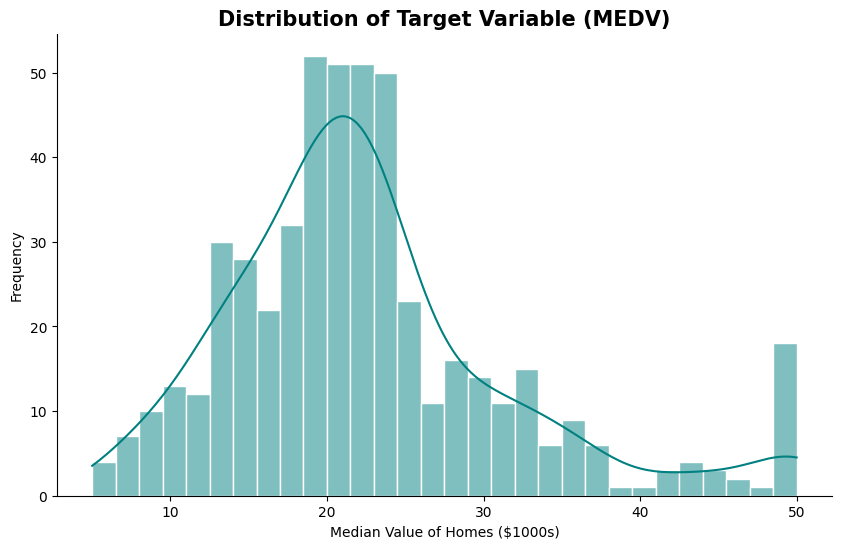

In [11]:
# Distribution of target variable MEDV
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='MEDV',
    kde=True,        #It shows the shape of your distribution
    color='teal',
    bins=30,         # Adjusting bins gives more detail to the distribution
    edgecolor='white'
)
plt.title('Distribution of Target Variable (MEDV)', fontsize=15, weight='bold')
plt.xlabel('Median Value of Homes ($1000s)')
plt.ylabel('Frequency')
sns.despine() # Makes the plot look much cleaner

plt.show()

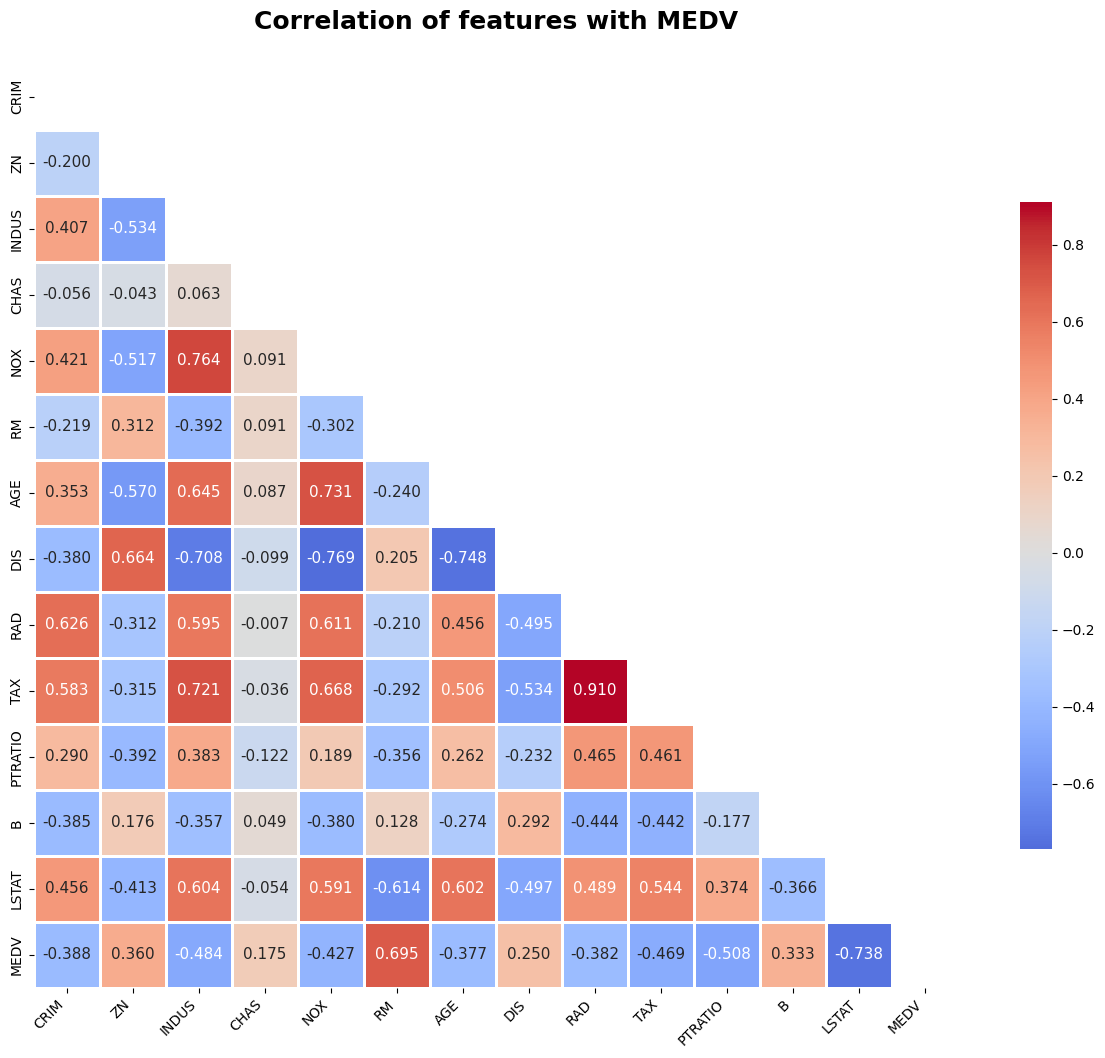

In [12]:
# Calculate the correlations first (The Math)
# Ensure only numeric columns are included
corr_matrix = df.select_dtypes(include='number').corr()

# Set up the figure
plt.figure(figsize=(16, 12))

# Create the mask for the lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the focused heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    annot_kws={"size": 11},
    cmap='coolwarm',
    center=0,
    linewidths=1,
    square=True,
    cbar_kws={"shrink": .7}
)

plt.title('Correlation of features with MEDV', fontsize=18, weight='bold', pad=25)
plt.xticks(rotation=45, ha='right')
plt.show()

---
### 📊 EDA Observations

**Target Variable (MEDV):**  
The distribution of MEDV is right-skewed, with the bulk of house values concentrated between \$15,000 and \$25,000, and a long tail extending toward $50,000. This indicates that higher-value properties are relatively rare in this dataset. The median (\$21,200) sits below the mean (\$22,533), which is characteristic of a right-skewed distribution.

**Correlation with MEDV (Key findings from heatmap):**  
- **RM (avg. rooms per dwelling):** Strongest positive predictor at **+0.695**. More rooms directly signal a larger, more valuable home expected and intuitive.  
- **LSTAT (% lower-status population):** Strongest negative predictor at **−0.738**. Higher concentrations of lower-income residents correlate strongly with reduced median home values.  
- **TAX (property tax rate per $10,000):** Negatively correlated at **−0.469**. Higher annual tax burdens reduce the attractiveness of a property to buyers.  
- **CRIM (crime rate):** Negatively correlated at **−0.388**. Neighbourhood safety is a known factor in residential property values.  
- **CHAS (Charles River adjacency):** Weakest positive predictor at **+0.175**, reflecting its binary (0/1) nature and limited geographic prevalence.

**Multicollinearity — RAD and TAX:**  
The heatmap reveals a strong inter-feature correlation of **0.910** between RAD (highway accessibility index) and TAX (property tax rate). This level of multicollinearity is notable and was explicitly tested: removing RAD from the feature set caused the Decision Tree R² to drop from 0.858 to 0.67, confirming that both features carry independent predictive signal despite their correlation. Both were retained in the final feature set.

> ⚠️ **Ethical Note — Column B:**  
> The column `B` is defined in the original dataset documentation as `1000(Bk - 0.63)²`, where `Bk` is the proportion of Black residents in a neighbourhood. This feature encodes a racial demographic proxy and reflects the racially discriminatory housing practices prevalent in the United States at the time this dataset was compiled (1978). While it is retained here for the purposes of reproducing the established benchmark, its inclusion in any real-world housing model would raise serious ethical concerns around fairness and discriminatory impact. It is flagged here as a reminder that data does not exist in a vacuum — the social context of features matters.


## **PHASE 4 — PREPROCESSING**

**Feature/Target Split:**  
`X` contains all 13 predictor columns (everything except MEDV). `y` contains MEDV — the quantity we are trying to predict. This separation is the fundamental setup for any supervised learning task.

**Train-Test Split:**  
An 80/20 split is applied using `random_state=42` for reproducibility. 80% of the 506 rows (≈404 rows) go to training; 20% (≈102 rows) are held out for testing. The test set is never seen by any model during training — it represents unseen data and gives us an honest estimate of generalisation performance.

**Scaling Decision:**  
Feature scaling was not applied to this dataset. Scikit-learn's `LinearRegression` uses Ordinary Least Squares (OLS) — a closed-form mathematical solution that is **scale-invariant**. Scaling the features would change the magnitude of the learned coefficients but would produce identical predictions, MSE, and R² values. The tree-based models (Decision Tree, Random Forest, XGBoost) are also inherently scale-invariant: they make decisions based on feature thresholds and split points, not distances or gradient magnitudes. No model in this comparison benefits from scaling.


In [13]:
# Define features and target
X = df.drop(columns='MEDV', axis=1)
y = df['MEDV']

In [14]:
# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **PHASE 5 — MODEL 1: LINEAR REGRESSION (BASELINE)**

**Why Linear Regression as the Baseline?**  
A baseline model establishes the minimum performance bar. Linear Regression is the appropriate choice here because it is the simplest model available for a continuous target variable — it assumes that the relationship between every feature and MEDV can be captured by a single straight line. This rigidity is precisely what makes it a useful reference: if a more flexible model cannot meaningfully outperform a model that forces every relationship into a linear form, that tells us something is wrong with the more complex model (or with the data).

**How it works:**  
`LinearRegression()` fits the equation `ŷ = β₀ + β₁X₁ + β₂X₂ + ... + β₁₃X₁₃` by minimising the sum of squared residuals (OLS). Each coefficient βᵢ represents the estimated change in MEDV for a one-unit increase in feature Xᵢ, holding all other features constant.

**Evaluation — MSE and R²:**  
- **MSE (Mean Squared Error):** The average of the squared differences between actual and predicted MEDV values. Lower is better. Squaring penalises large errors more heavily than small ones.  
- **R² (Coefficient of Determination):** The proportion of variance in MEDV that the model explains. Ranges from 0 to 1. A value of 1.0 means perfect prediction; 0.0 means the model does no better than simply predicting the mean MEDV for every row.

The scatter plot (Actual vs Predicted) visualises how closely predictions track reality. Points lying on or near the red identity line (y = ŷ) represent accurate predictions. Scatter around the line reveals where the model under- or over-predicts.


In [15]:
#Train model
baseline = LinearRegression()
baseline.fit(X_train, y_train)

LinearRegression()

In [16]:
#predict
y_pred_baseline = baseline.predict(X_test)

# Evaluation
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Mean Squared Error (MSE): {mse_baseline}")
print(f"R-squared (R2): {r2_baseline}")

Mean Squared Error (MSE): 24.291119474973478
R-squared (R2): 0.6687594935356326


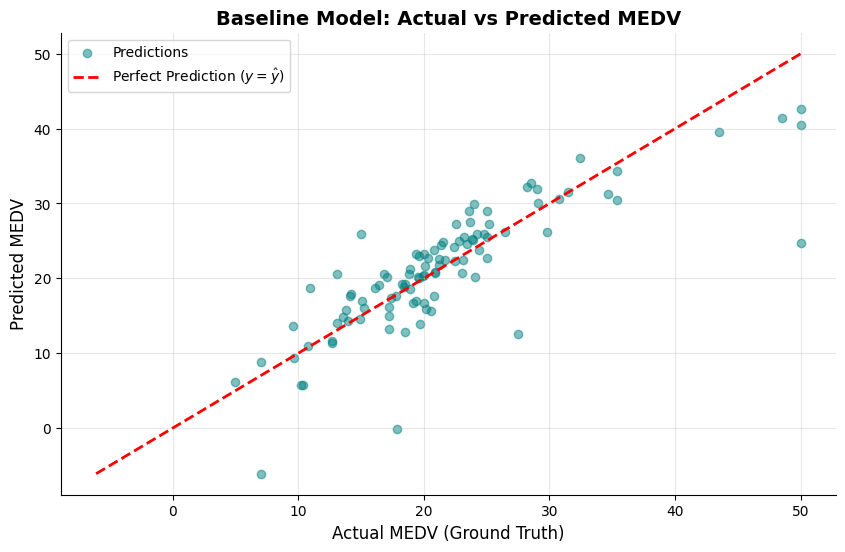

In [17]:
# Scatter plot: Actual vs Predicted MEDV
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_baseline, alpha=0.5, color='teal', label='Predictions')

#  the "Perfect Prediction" Line (the identity line)
min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction ($y = \hat{y}$)')

plt.title('Baseline Model: Actual vs Predicted MEDV', fontsize=14, weight='bold')
plt.xlabel('Actual MEDV (Ground Truth)', fontsize=12)
plt.ylabel('Predicted MEDV', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
sns.despine()

plt.show()

## **PHASE 6 — MODEL 2: DECISION TREE REGRESSOR**

**Why Decision Tree?**  
Linear Regression constrains every feature-target relationship to a single linear form. In reality, housing prices are non-linear: beyond a certain point, an extra room adds less marginal value, or the effect of crime rate on price depends on other neighbourhood factors. A Decision Tree breaks the feature space into rectangular regions through recursive binary splitting — at each node, it selects the feature and threshold that minimises prediction error in the resulting sub-groups.

This means the Decision Tree can capture non-linear relationships and interactions between features, without any linearity assumption.

**Key limitation — overfitting:**  
With `DecisionTreeRegressor(random_state=42)` and no `max_depth` constraint, the tree is allowed to grow until each leaf is pure (or nearly so). On a dataset of 506 rows, this creates a risk of memorising the training data rather than learning generalisable patterns. The random_state ensures reproducibility but does not control depth. This overfitting tendency is the specific weakness that Random Forest is designed to address.


In [18]:
# Train model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [19]:
# predict
y_pred_dt = dt.predict(X_test)

# evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Mean Squared Error (MSE): {mse_dt}")
print(f"R-squared (R2): {r2_dt}")

Mean Squared Error (MSE): 10.416078431372549
R-squared (R2): 0.8579634380978161


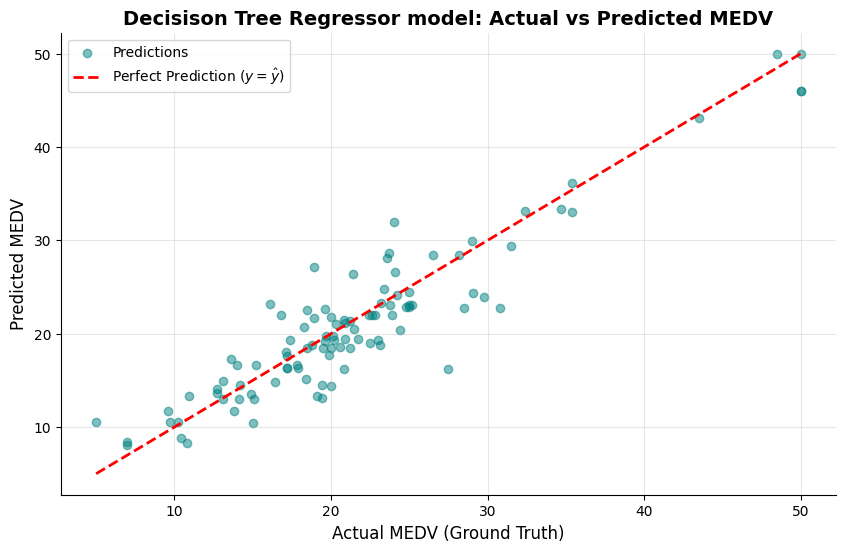

In [20]:
# Scatter plot: Actual vs Predicted MEDV(DecisionTreeRegression)
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_dt, alpha=0.5, color='teal', label='Predictions')

#  the "Perfect Prediction" Line (the identity line)
min_val = min(y_test.min(), y_pred_dt.min())
max_val = max(y_test.max(), y_pred_dt.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction ($y = \hat{y}$)')

plt.title('Decisison Tree Regressor model: Actual vs Predicted MEDV', fontsize=14, weight='bold')
plt.xlabel('Actual MEDV (Ground Truth)', fontsize=12)
plt.ylabel('Predicted MEDV', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
sns.despine()

plt.show()

## **PHASE 7 — MODEL 3: RANDOM FOREST REGRESSOR**

**Why Random Forest?**  
Random Forest is an ensemble method that builds `n_estimators` Decision Trees in parallel, each trained on a **random bootstrap sample** of the training data (bagging) and restricted to a **random subset of features** at each split. The final prediction is the average of all individual tree predictions.

These two sources of randomness — data subsampling and feature subsampling — prevent any single tree from memorising the full training set. Each tree sees a different slice of the data and learns slightly different patterns; averaging their predictions smooths out individual errors and dramatically reduces the variance that causes a single deep Decision Tree to overfit.

**Parameters:**  
- `n_estimators=100` — 100 trees are built and averaged. More trees generally improve stability but with diminishing returns.  
- `random_state=42` — ensures reproducible random sampling for both data bootstrap and feature selection at each split.

The expected performance improvement over Decision Tree comes directly from this variance reduction mechanism.


In [21]:
# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
# predict
y_pred_rf = rf.predict(X_test)

#evalaute
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Squared Error (MSE): {mse_rf}")
print(f"R-squared (R2): {r2_rf}")

Mean Squared Error (MSE): 7.901513892156864
R-squared (R2): 0.8922527442109116


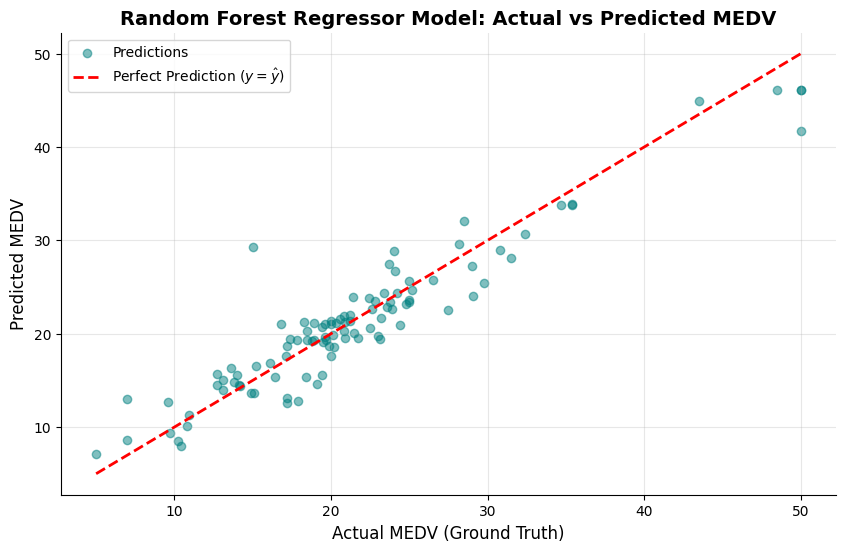

In [23]:
# Scatter plot: Actual vs Predicted MEDV(RandomForestRegressor)
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal', label='Predictions')

#  the "Perfect Prediction" Line (the identity line)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction ($y = \hat{y}$)')

plt.title('Random Forest Regressor Model: Actual vs Predicted MEDV', fontsize=14, weight='bold')
plt.xlabel('Actual MEDV (Ground Truth)', fontsize=12)
plt.ylabel('Predicted MEDV', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
sns.despine()

plt.show()

## **PHASE 8 — MODEL 4: XGBOOST REGRESSOR**

**Why XGBoost?**  
XGBoost (Extreme Gradient Boosting) belongs to the same tree family as Decision Tree and Random Forest, but its learning strategy is fundamentally different. Where Random Forest builds trees **in parallel** and averages them, XGBoost builds trees **sequentially** — each new tree is trained specifically to correct the residual errors of all the trees that came before it.

This is the key mechanism of **gradient boosting**: at each stage, the algorithm computes the gradient of the loss function (how wrong the current ensemble is), and the next tree is fitted to those gradients. The result is a model that continuously refines its own predictions, rather than just averaging independent estimates.

**Why this outperforms Random Forest:**  
Random Forest reduces variance by averaging. XGBoost reduces both variance and bias by iteratively correcting mistakes. It can model finer-grained patterns in the residuals that Random Forest leaves on the table.

**Parameters:**  
- `n_estimators=100` — number of sequential boosting rounds  
- `random_state=42` — reproducibility  
- `verbosity=0` — suppresses training output to keep the notebook clean


In [24]:
#Train model
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
# predict
y_pred_xgb = xgb.predict(X_test)

# evaluation
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Mean Squared Error (MSE): {mse_xgb}")
print(f"R-squared (R2): {r2_xgb}")

Mean Squared Error (MSE): 6.909231565384943
R-squared (R2): 0.9057837838492537


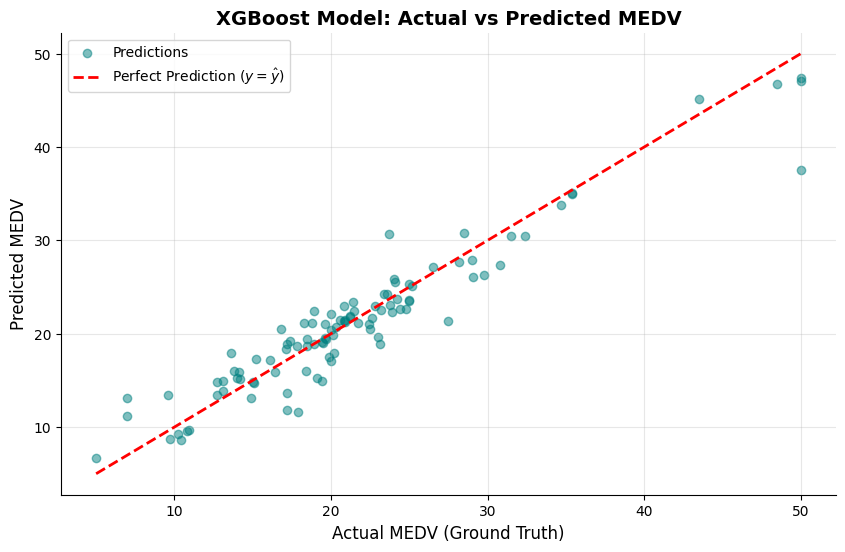

In [26]:
# Scatter plot: Actual vs Predicted MEDV(XGBoost)
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='teal', label='Predictions')

#  the "Perfect Prediction" Line (the identity line)
min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction ($y = \hat{y}$)')

plt.title('XGBoost Model: Actual vs Predicted MEDV', fontsize=14, weight='bold')
plt.xlabel('Actual MEDV (Ground Truth)', fontsize=12)
plt.ylabel('Predicted MEDV', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
sns.despine()

plt.show()

## **PHASE 9 — MODEL COMPARISON**

This phase consolidates the results from all four models into a single comparison table and two bar charts — one for R² (higher is better) and one for MSE (lower is better).

The progression from baseline to XGBoost represents a deliberate model selection strategy: each model was chosen specifically because it addresses a limitation in the one before it. The comparison table makes that progression quantifiable.


In [27]:
# build comparison table
results = pd.DataFrame({
    'Model': ['Baseline', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'MSE': [mse_baseline, mse_dt, mse_rf, mse_xgb],
    'R2': [r2_baseline, r2_dt, r2_rf, r2_xgb]
})

print(results)

           Model        MSE        R2
0       Baseline  24.291119  0.668759
1  Decision Tree  10.416078  0.857963
2  Random Forest   7.901514  0.892253
3        XGBoost   6.909232  0.905784


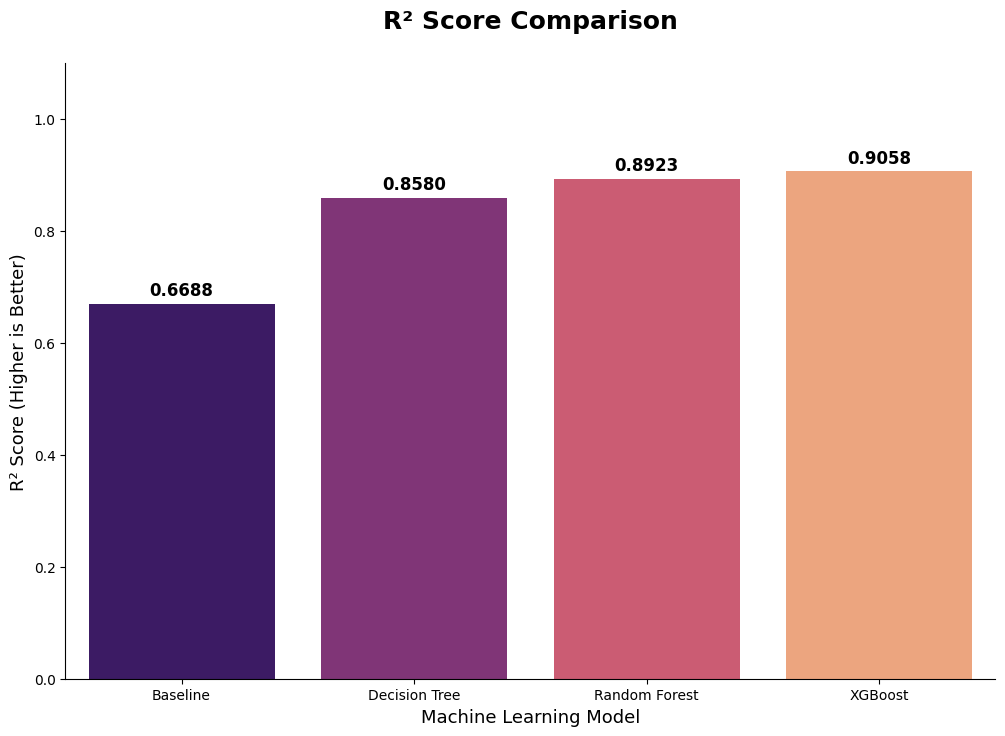

In [28]:
# Bar chart comparing R² scores across all four models
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=results,
    x='Model',
    y='R2',
    palette='magma', # We use 'palette' to give each bar a unique color
    hue='Model',     # We set 'hue' to 'Model' to ensure Seaborn maps the colors correctly
    legend=False
)

# Add the "Insight" labels: putting the exact R² value on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=12, weight='bold', color='black')

plt.title('R² Score Comparison', fontsize=18, weight='bold', pad=25)
plt.xlabel('Machine Learning Model', fontsize=13)
plt.ylabel('R² Score (Higher is Better)', fontsize=13)
plt.ylim(0, 1.1) # Gives room for the labels on top
sns.despine()

plt.show()

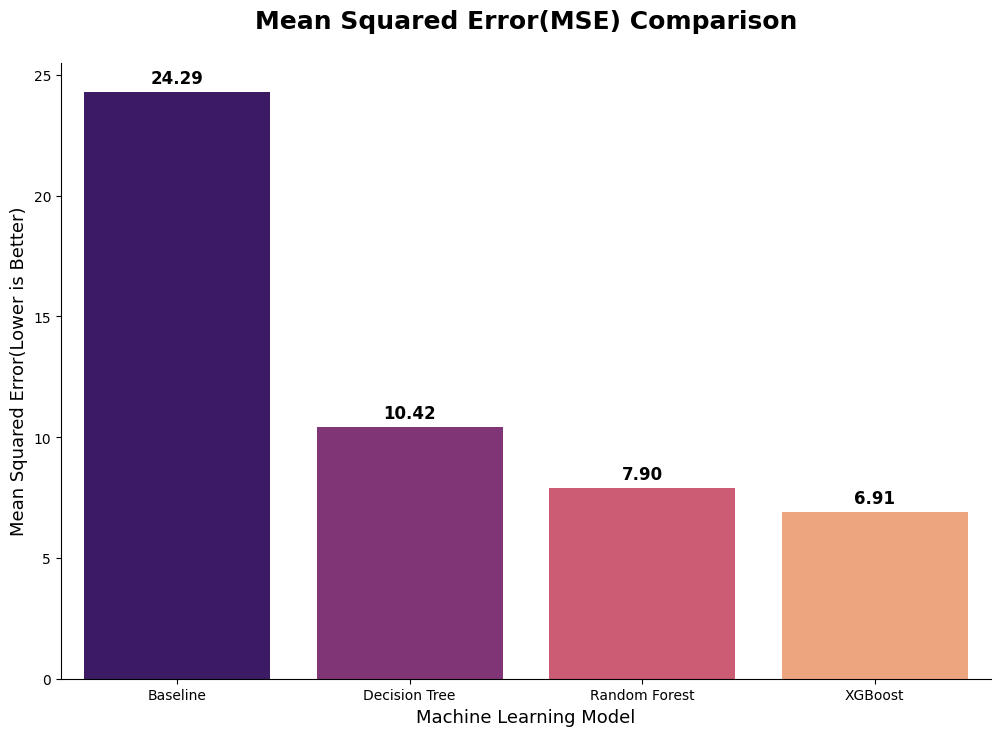

In [29]:
# Bar chart comparing MSE scores across all four models
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=results,
    x='Model',
    y='MSE',
    palette='magma', # We use 'palette' to give each bar a unique color
    hue='Model',     # We set 'hue' to 'Model' to ensure Seaborn maps the colors correctly
    legend=False
)

# Add the "Insight" labels: putting the exact R² value on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=12, weight='bold', color='black')

plt.title('Mean Squared Error(MSE) Comparison', fontsize=18, weight='bold', pad=25)
plt.xlabel('Machine Learning Model', fontsize=13)
plt.ylabel('Mean Squared Error(Lower is Better)', fontsize=13)
sns.despine()

plt.show()

## **PHASE 10 — WRITTEN INSIGHTS**

### Model Performance Summary

| Model | MSE | R² |
|---|---|---|
| Linear Regression (Baseline) | 24.2911 | 0.6688 |
| Decision Tree | 10.4161 | 0.8580 |
| Random Forest | 7.9015 | 0.8923 |
| XGBoost | 6.9092 | 0.9058 |

---

### Key Findings

**1. Linear Regression established a meaningful but limited baseline.**  
With an R² of **0.669** and MSE of **24.29**, the baseline model explained approximately 67% of the variance in median home values. Given that this model assumes every relationship between a feature and MEDV is strictly linear and additive, an R² of 0.67 is not a bad starting point — it tells us the features carry real signal. However, the residual 33% of unexplained variance, reflected in an MSE of 24.29 (equivalent to average prediction errors of roughly ±$4,900 in home value), indicates that house pricing involves non-linear dynamics that a linear model structurally cannot capture.

**2. Decision Tree produced the largest single-model improvement.**  
By moving from Linear Regression to Decision Tree, MSE dropped from 24.29 to **10.42** — a reduction of over 57% — while R² jumped to **0.858**. This is the clearest evidence in the results that the feature-MEDV relationships are substantially non-linear. A Decision Tree has no linearity constraint: it partitions the feature space through recursive binary splits, capturing thresholds and interaction effects that Linear Regression cannot model. However, with no `max_depth` set, this model is at risk of overfitting — it may have memorised patterns specific to the training set rather than learned generalisable structure.

**3. Random Forest reduced overfitting and improved consistency.**  
Random Forest achieved an MSE of **7.90** and R² of **0.892** — a meaningful step beyond the Decision Tree. The improvement comes from bagging: 100 Decision Trees each trained on a random bootstrap sample of the data, with a random feature subset considered at every split. By averaging across trees that have each seen only a partial view of the training data, the model reduces the variance that a single deep tree accumulates. The key gain here is not raw accuracy alone but stability — the predictions are more consistent and less sensitive to the specific rows that ended up in the training set.

**4. XGBoost delivered the best performance across both metrics.**  
With an MSE of **6.91** and R² of **0.906**, XGBoost outperformed every other model in this comparison. The gap over Random Forest (MSE reduction of ~1 point, R² gain of ~0.014) reflects the power of sequential gradient boosting: rather than averaging independent trees, XGBoost builds each successive tree to directly correct the residual errors of the ensemble so far. This iterative error correction allows the model to capture finer-grained patterns in the data that Random Forest leaves unresolved.

**5. The strongest individual predictors confirmed domain expectations.**  
The correlation heatmap identified **RM** (average rooms per dwelling, +0.695) and **LSTAT** (% lower-status population, −0.738) as the features most strongly correlated with MEDV. These findings align with established real estate economics: property size (proxied by room count) and neighbourhood socioeconomic composition are primary determinants of residential market value.

**6. Multicollinearity between RAD and TAX was tested empirically.**  
RAD (highway accessibility index) and TAX (property tax rate) showed an inter-feature correlation of 0.910 — the highest multicollinearity pair in the dataset. To determine whether one was redundant, RAD was removed and all four models were retrained. The result was instructive: Decision Tree R² collapsed from 0.858 to 0.67, and XGBoost R² declined from 0.906 to 0.902. Only Random Forest showed a marginal improvement. This demonstrated that despite their high correlation, both features carry independent predictive signal — RAD likely captures a dimension of neighbourhood connectivity or urban structure that is distinct from the tax burden encoded in TAX. Both features were retained in the final model.

---

### Conclusion

This task demonstrated the practical value of progressively increasing model complexity in a structured way. Starting from a simple linear baseline made it possible to measure exactly how much each additional layer of flexibility contributed. The results confirm the expected ranking — XGBoost ≥ Random Forest > Decision Tree > Linear Regression — and the magnitude of improvement at each step validates that this dataset contains non-linear structure that simpler models genuinely cannot capture. An R² of 0.906 from XGBoost means the final model accounts for over 90% of the variance in Boston neighbourhood home values using only 13 socioeconomic and structural features.

---
*Codveda Data Science Internship — Level 2, Task 1 | Deborah Olofin*